In [ ]:
from pathlib import Path
from abc_atlas_access.abc_atlas_cache.abc_project_cache import AbcProjectCache
import scanpy as sc
import numpy as np
import pandas as pd
import torch
import concord as ccd
import anndata as ad
import copy
import matplotlib.pyplot as plt
import time
from scipy.stats import linregress
import scipy
import sys

In [33]:
print('pyhon version:')
sys.version

pyhon version:


'3.14.3 | packaged by conda-forge | (main, Feb  9 2026, 21:56:48) [MSC v.1944 64 bit (AMD64)]'

In [29]:
torch.__version__

'2.10.0+cpu'

In [34]:
np.__version__

'2.4.2'

In [27]:
ccd.__version__

'1.0.13'

In [35]:
pd.__version__

'2.3.3'

In [28]:
sc.__version__

C:\Users\jonat\AppData\Local\Temp\ipykernel_11428\4147423214.py:1: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  sc.__version__


'1.12'

In [37]:
scipy.__version__

'1.17.1'

In [41]:
ad.__version__


C:\Users\jonat\AppData\Local\Temp\ipykernel_11428\3903165381.py:1: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  ad.__version__


'0.12.10'

In [42]:
import matplotlib as mpl

mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

plt.rcParams['svg.fonttype'] = 'none'

In [43]:
download_base = Path('data/abc_atlas')
abc_cache = AbcProjectCache.from_cache_dir(download_base)

abc_cache.current_manifest

'releases/20260415/manifest.json'

List the all of the different releases available and usable by the cache object we have just loaded.

#### Downloading individual expression matrix files

In [44]:
cortex_matrix_labels = [
    'WMB-10Xv2-Isocortex-1/log2',
    'WMB-10Xv2-Isocortex-2/log2',
    'WMB-10Xv2-Isocortex-3/log2',
    'WMB-10Xv2-Isocortex-4/log2',
    'WMB-10Xv3-Isocortex-1/log2',
    'WMB-10Xv3-Isocortex-2/log2'
]

In [45]:
sc_path = abc_cache.get_file_path(directory='WMB-10Xv2', file_name=cortex_matrix_labels[0])

WMB-10Xv2-Isocortex-1-log2.h5ad: 100%|██████████| 8.60G/8.60G [06:30<00:00, 22.0MMB/s]    


In [46]:
icortexv2_1 = ad.read_h5ad(sc_path)

In [47]:
pia_layer_cells = pd.read_csv("rs_seqFISH_brain_all_fov/PIA_layer_cells.csv")

In [48]:
pia_layer_cells['cell'] = pia_layer_cells['pos_cell'] 

In [49]:
pia_layer_cells.set_index(['pos', 'cell'], inplace=True)

In [50]:
gxcm = pd.read_csv("rs_seqFISH_brain_all_fov/cell_x_gene_matrix.csv") ##"sfmb_cbgm.csv")

In [51]:
gxcm.set_index(['pos', "cell"], inplace=True)
gxcm

Aars  Aco2  Actn4  Aebp1  Aqp1  Arf1  Arpc2  Arpc5  Cct3  Cct5  ...  \
pos cell                                                                  ...   
0   5      1.0   4.0    7.0    0.0   5.0   1.0    4.0    1.0   3.0   1.0  ...   
    8      4.0   9.0    2.0    1.0  21.0   8.0    2.0    1.0   8.0   3.0  ...   
    9      1.0   9.0    8.0    4.0  12.0   7.0    3.0    2.0   4.0   6.0  ...   
    10     1.0   2.0    0.0    0.0   7.0   0.0    0.0    0.0   1.0   6.0  ...   
    11     3.0   4.0    4.0    0.0  10.0   4.0    2.0    0.0   7.0   6.0  ...   
...        ...   ...    ...    ...   ...   ...    ...    ...   ...   ...  ...   
76  83     6.0   4.0   17.0    0.0   4.0  27.0   15.0    3.0   6.0   0.0  ...   
    84     3.0   1.0    5.0    0.0   1.0   7.0    6.0    0.0   0.0   0.0  ...   
    85     0.0   0.0    0.0    0.0   0.0   2.0    3.0    0.0   0.0   0.0  ...   
    87     0.0   0.0    1.0    0.0   0.0   0.0    1.0    1.0   0.0   0.0  ...   
    88     0.0   0.0    0.0    0.0   0.0   0.0    0.0    0.0   0.0   0.0  ...   

          Xdh  Ybx1  Ywhae  Ywhag  Ywhah  Ywhaq  Ywhaz  Zfp36l1  Zfp36l2  Zyx  
pos cell                                                                       
0   5     0.0   1.0    1.0    2.0    7.0    0.0    6.0      5.0      1.0  4.0  
    8     1.0   0.0    0.0    5.0    3.0    1.0   11.0      2.0      5.0  0.0  
    9     0.0   1.0    7.0    8.0    7.0    3.0   11.0      2.0      3.0  3.0  
    10    0.0   0.0    0.0    6.0    5.0    0.0    3.0      1.0      0.0  0.0  
    11    2.0   0.0    0.0    5.0    5.0    0.0    4.0      8.0      3.0  2.0  
...       ...   ...    ...    ...    ...    ...    ...      ...      ...  ...  
76  83    0.0   0.0    2.0   52.0    0.0    1.0   66.0      3.0      0.0  2.0  
    84    0.0   1.0    1.0   14.0    0.0    0.0   27.0      1.0      0.0  0.0  
    85    0.0   0.0    0.0    1.0    0.0    0.0    2.0      0.0      0.0  0.0  
    87    0.0   0.0    0.0    0.0    0.0    0.0    3.0      0.0      0.0  0.0  
    88    0.0   0.0    0.0    0.0    0.0    0.0    1.0      0.0      0.0  0.0  

[9138 rows x 271 columns]

In [52]:
pia_cell_indices = pd.merge(gxcm, pia_layer_cells, left_index=True, right_index=True, how='inner').index

In [53]:
gxcm.drop(pia_cell_indices, inplace=True)

In [54]:
gxcm_filt = gxcm.loc[gxcm.sum(axis=1) > 300]

In [55]:
rssf = ad.AnnData(gxcm_filt.reset_index(drop=True))

c:\Users\jonat\miniconda3\envs\concord_brain_atlas\Lib\functools.py:982: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


In [56]:
rssf.obs['pos'] = np.array(gxcm_filt.reset_index()["pos"])
rssf.obs['cell'] = np.array(gxcm_filt.reset_index()["cell"])

In [57]:
icortexv2_1_genes = copy.deepcopy(icortexv2_1.var)

In [58]:
icortexv2_1_genes_gs_ind = icortexv2_1_genes.reset_index().set_index("gene_symbol")

In [59]:
gene_ids = icortexv2_1_genes_gs_ind.loc[rssf.var.index]['gene_identifier']

In [60]:
sc.pp.filter_cells(icortexv2_1, min_genes=10)
sc.pp.normalize_total(icortexv2_1)

In [61]:
icortexv2_1_rssf_genes = icortexv2_1[:, gene_ids]

In [23]:
wmb10x_cell_md = abc_cache.get_metadata_dataframe(directory='WMB-10X', file_name='cell_metadata_with_cluster_annotation')

c:\Users\jonat\miniconda3\envs\concord_brain_atlas\Lib\site-packages\abc_atlas_access\abc_atlas_cache\abc_project_cache.py:643: DtypeWarning: Columns (16) have mixed types. Specify dtype option on import or set low_memory=False.
  return pd.read_csv(path, **kwargs)


In [24]:
icdx1v2_md = wmb10x_cell_md.loc[wmb10x_cell_md['feature_matrix_label'] == 'WMB-10Xv2-Isocortex-1']

In [25]:
icdx1v2_md.set_index("cell_label", inplace=True)

In [26]:
icortexv2_1_rssf_genes.obs["class"] = icdx1v2_md["class"]

C:\Users\jonat\AppData\Local\Temp\ipykernel_24972\23914575.py:1: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  icortexv2_1_rssf_genes.obs["class"] = icdx1v2_md["class"]


In [27]:
icortexv2_1_rssf_genes.obs["class_color"] = icdx1v2_md["class_color"]

In [28]:
icortexv2_1_rssf_genes.obs['class'].fillna("unlabeled", inplace=True)

In [29]:
np.unique(icortexv2_1_rssf_genes.obs['class'], return_counts=True)

(array(['01 IT-ET Glut', '02 NP-CT-L6b Glut', '03 OB-CR Glut',
        '04 DG-IMN Glut', '05 OB-IMN GABA', '06 CTX-CGE GABA',
        '07 CTX-MGE GABA', '08 CNU-MGE GABA', '09 CNU-LGE GABA',
        '10 LSX GABA', '11 CNU-HYa GABA', '13 CNU-HYa Glut', '14 HY Glut',
        '19 MB Glut', '25 Pineal Glut', '30 Astro-Epen', '31 OPC-Oligo',
        '32 OEC', '33 Vascular', '34 Immune', 'unlabeled'], dtype=object),
 array([ 80112, 112145,    317,      7,    345,  24382,  25988,    814,
           930,      1,     42,     43,      1,      1,     76,    411,
          1823,      7,   1173,    158,   1264]))

In [30]:
class_cnts = pd.DataFrame(np.transpose(np.unique(icortexv2_1_rssf_genes.obs['class'], return_counts=True)), columns = ["class", "counts"])

In [31]:
class_cnts["pct"] = class_cnts["counts"]/np.sum(class_cnts["counts"])

In [32]:
nonrare_classes = list(class_cnts.loc[class_cnts.counts > 9, 'class'])

In [33]:
labeled_non_rare_inds = [c in nonrare_classes and c != "unlabeled" for c in icortexv2_1_rssf_genes.obs['class']]

In [34]:
icortexv2_1_rssf_genes_nrsc = icortexv2_1_rssf_genes[labeled_non_rare_inds, :]

In [35]:
sc.tl.rank_genes_groups(icortexv2_1_rssf_genes_nrsc, "class", method="wilcoxon")

c:\Users\jonat\miniconda3\envs\concord_brain_atlas\Lib\site-packages\anndata\_core\anndata.py:1208: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
c:\Users\jonat\miniconda3\envs\concord_brain_atlas\Lib\site-packages\anndata\_core\anndata.py:1208: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


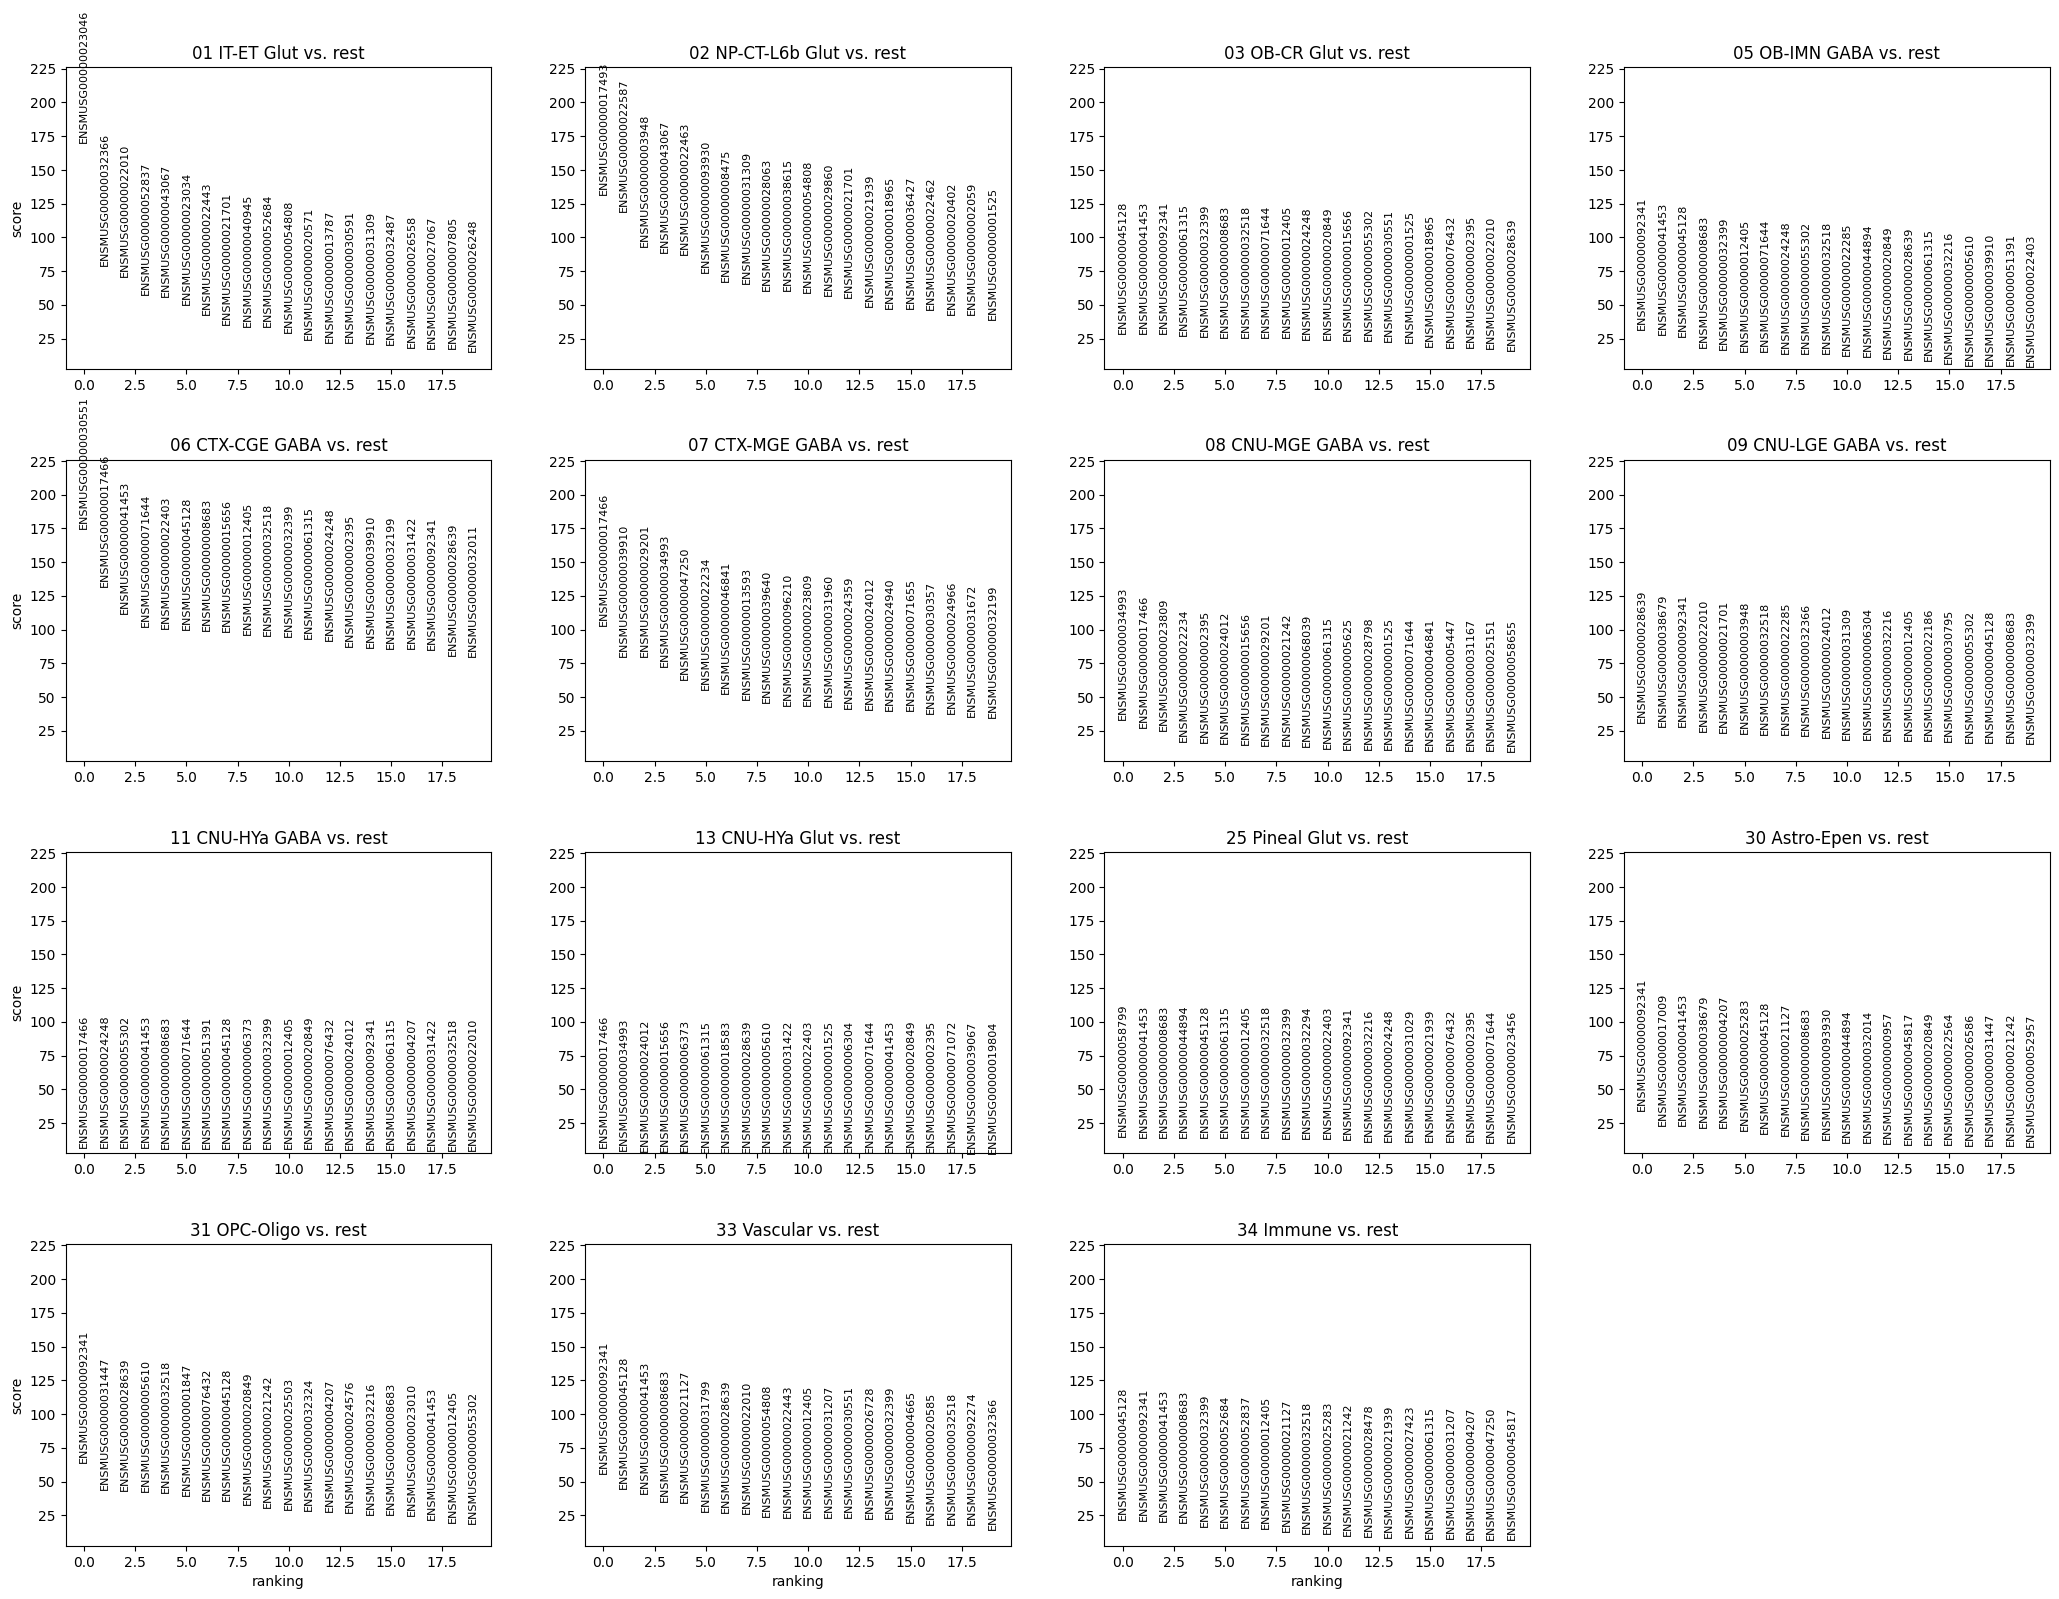

In [36]:
sc.pl.rank_genes_groups(icortexv2_1_rssf_genes_nrsc)

In [37]:
gs = np.unique([g for grge in np.array(icortexv2_1_rssf_genes_nrsc.uns['rank_genes_groups']['names'][:5]) for g in grge])

In [38]:
sc.pp.filter_cells(rssf, min_genes=100)
rssf.raw = rssf.copy()
sc.pp.normalize_total(rssf)


In [39]:
sc.pp.log1p(rssf)


In [40]:
def subsample_i(subclass, seed):
    print(len(subclass[1]))
    if len(subclass[1]) > 1000:
        return subclass[1].sample(n=1000, random_state = seed)
    else:
        return subclass[1]

In [41]:
subsamples = []
for i in range(10):
    samp = pd.concat(list(map(lambda s: subsample_i(s,i), icortexv2_1_rssf_genes_nrsc.obs.groupby("class"))))
    subsamples.append(copy.deepcopy(icortexv2_1_rssf_genes_nrsc)[samp.index,:])

C:\Users\jonat\AppData\Local\Temp\ipykernel_24972\3339800461.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  samp = pd.concat(list(map(lambda s: subsample_i(s,i), icortexv2_1_rssf_genes_nrsc.obs.groupby("class"))))


80112
112145
317
345
24382
25988
814
930
42
43
76
411
1823
1173
158


C:\Users\jonat\AppData\Local\Temp\ipykernel_24972\3339800461.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  samp = pd.concat(list(map(lambda s: subsample_i(s,i), icortexv2_1_rssf_genes_nrsc.obs.groupby("class"))))
C:\Users\jonat\AppData\Local\Temp\ipykernel_24972\3339800461.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  samp = pd.concat(list(map(lambda s: subsample_i(s,i), icortexv2_1_rssf_genes_nrsc.obs.groupby("class"))))


80112
112145
317
345
24382
25988
814
930
42
43
76
411
1823
1173
158
80112
112145
317
345
24382
25988
814
930
42
43
76
411
1823
1173
158


C:\Users\jonat\AppData\Local\Temp\ipykernel_24972\3339800461.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  samp = pd.concat(list(map(lambda s: subsample_i(s,i), icortexv2_1_rssf_genes_nrsc.obs.groupby("class"))))
C:\Users\jonat\AppData\Local\Temp\ipykernel_24972\3339800461.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  samp = pd.concat(list(map(lambda s: subsample_i(s,i), icortexv2_1_rssf_genes_nrsc.obs.groupby("class"))))


...

C:\Users\jonat\AppData\Local\Temp\ipykernel_24972\3339800461.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  samp = pd.concat(list(map(lambda s: subsample_i(s,i), icortexv2_1_rssf_genes_nrsc.obs.groupby("class"))))
C:\Users\jonat\AppData\Local\Temp\ipykernel_24972\3339800461.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  samp = pd.concat(list(map(lambda s: subsample_i(s,i), icortexv2_1_rssf_genes_nrsc.obs.groupby("class"))))


80112
112145
317
345
24382
25988
814
930
42
43
76
411
1823
1173
158
80112
112145
317
345
24382
25988
814
930
42
43
76
411
1823
1173
158


C:\Users\jonat\AppData\Local\Temp\ipykernel_24972\3339800461.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  samp = pd.concat(list(map(lambda s: subsample_i(s,i), icortexv2_1_rssf_genes_nrsc.obs.groupby("class"))))
C:\Users\jonat\AppData\Local\Temp\ipykernel_24972\3339800461.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  samp = pd.concat(list(map(lambda s: subsample_i(s,i), icortexv2_1_rssf_genes_nrsc.obs.groupby("class"))))


80112
112145
317
345
24382
25988
814
930
42
43
76
411
1823
1173
158
80112
112145
317
345
24382
25988
814
930
42
43
76
411
1823
1173
158
80112
112145
317
345
24382
25988
814
930
42
43
76
411
1823
1173
158


C:\Users\jonat\AppData\Local\Temp\ipykernel_24972\3339800461.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  samp = pd.concat(list(map(lambda s: subsample_i(s,i), icortexv2_1_rssf_genes_nrsc.obs.groupby("class"))))


In [42]:
rep_models = []
for samp in subsamples:
    proj_name = "rs_seqFISH_brain_atlas_label_transfer"
    save_dir = f"/save/dev_{proj_name}-{time.strftime('%b%d')}/"
    save_dir = Path(save_dir)
    save_dir.mkdir(parents=True, exist_ok=True)
    device = torch.device('cuda:3' if torch.cuda.is_available() else 'cpu')
    file_suffix = f"{time.strftime('%b%d-%H%M')}"

    cur_ccd = ccd.Concord(adata=samp, #icortexv2_1_rssf_genes_nrsc_sub, 
                      class_key = 'class',
                      use_classifier = True,
                      clr_beta=1.0,
                      p_intra_knn=0,
                      n_epochs=10,
                      preload_dense=True, 
                      verbose=False,
                      train_frac=0.9, # Use 90% of data for training, and 10% for validation
                      save_dir=save_dir / 'model/', # directory to save model checkpoints
                      ) 
    # Encode data, saving the latent embedding in adata.obsm['Concord']
    cur_ccd.fit_transform(output_key='Concord')
    rep_models.append(cur_ccd)
    

concord - WARNING - No input feature list provided. It is recommended to first select features using the command `concord.ul.select_features()`.
concord - WARNING - domain/batch information not found, all samples will be treated as from single domain/batch.


concord - WARNING - Only one domain found in the data. Setting p_intra_domain to 1.0.


c:\Users\jonat\miniconda3\envs\concord_brain_atlas\Lib\site-packages\concord\concord.py:910: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs[self.config.domain_key] = pd.Series(data='single_domain', index=adata.obs_names).astype('category')


Epoch 0 Training


c:\Users\jonat\miniconda3\envs\concord_brain_atlas\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


...

c:\Users\jonat\miniconda3\envs\concord_brain_atlas\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\jonat\miniconda3\envs\concord_brain_atlas\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\jonat\miniconda3\envs\concord_brain_atlas\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifi

Epoch 8 Validation
Epoch 9 Training


c:\Users\jonat\miniconda3\envs\concord_brain_atlas\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\jonat\miniconda3\envs\concord_brain_atlas\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\jonat\miniconda3\envs\concord_brain_atlas\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifi

Epoch 9 Validation


c:\Users\jonat\miniconda3\envs\concord_brain_atlas\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\jonat\miniconda3\envs\concord_brain_atlas\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\jonat\miniconda3\envs\concord_brain_atlas\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifi

In [43]:
rssf.obs["class"] = "unlabeled"

In [44]:
rssf.obs['class'] = rssf.obs['class'].astype('category')

In [45]:
cur_ccd.predict_adata(rssf, output_key='Concord')

concord - WARNING - domain/batch information not found, all samples will be treated as from single domain/batch.
concord - WARNING - Only one domain found in the data. Setting p_intra_domain to 1.0.


c:\Users\jonat\miniconda3\envs\concord_brain_atlas\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


In [46]:
rssf_pred_class_cnts = pd.DataFrame(np.transpose(np.unique(rssf.obs['Concord_class_pred'], return_counts=True)), columns = ["Concord_class_pred", "counts"])

In [47]:
rssf_pred_class_cnts["pct"] = rssf_pred_class_cnts["counts"]/np.sum(rssf_pred_class_cnts["counts"])

In [48]:
nonrare_pred_subclasses = list(rssf_pred_class_cnts.loc[rssf_pred_class_cnts.counts > 10, 'Concord_class_pred'])

In [49]:
pred_non_rare_inds = [c in nonrare_pred_subclasses for c in rssf.obs.Concord_class_pred]

In [50]:
rssf_nrsc = rssf[pred_non_rare_inds, :]

In [51]:
sc.tl.rank_genes_groups(rssf_nrsc, "Concord_class_pred", method="wilcoxon")

c:\Users\jonat\miniconda3\envs\concord_brain_atlas\Lib\site-packages\anndata\_core\anndata.py:1208: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
c:\Users\jonat\miniconda3\envs\concord_brain_atlas\Lib\site-packages\anndata\_core\anndata.py:1208: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


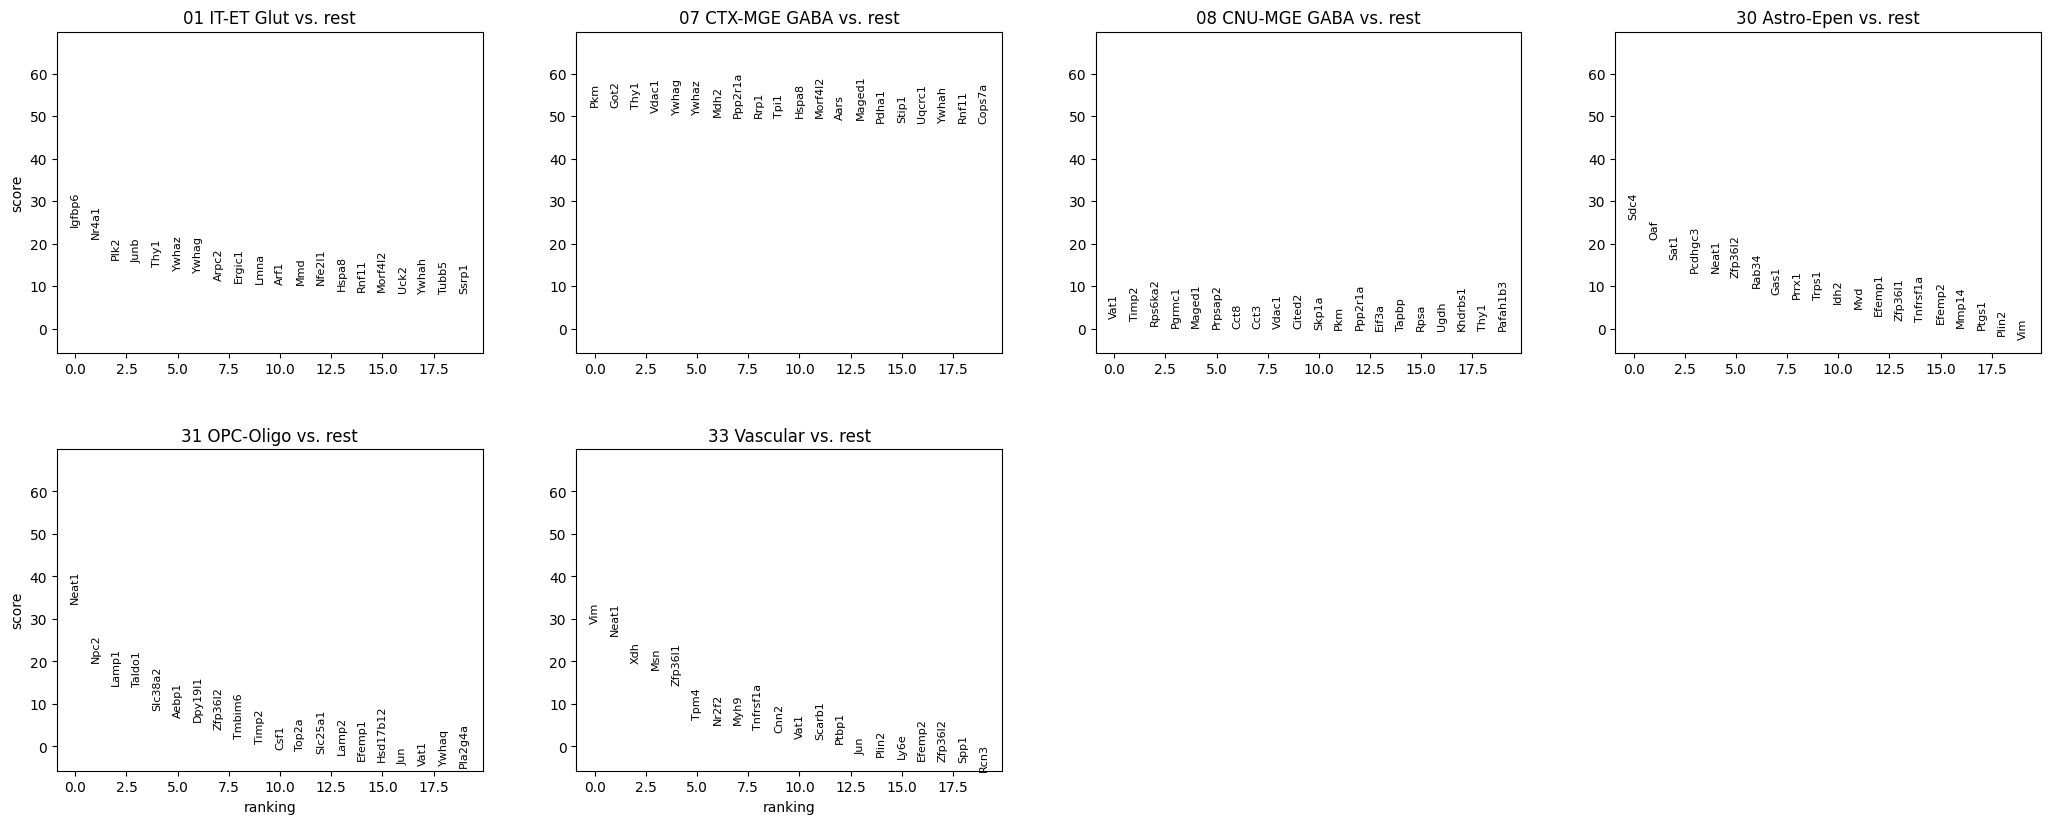

In [52]:
sc.pl.rank_genes_groups(rssf_nrsc)

In [53]:
gs_sc_pred = np.unique([g for grge in np.array(rssf_nrsc.uns['rank_genes_groups']['names'][:5]) for g in grge])

In [54]:
rssf_nrsc.uns['gs_sc_pred']  = gs_sc_pred

In [55]:
gs_sc_pred8 = np.unique([g for grge in np.array(rssf_nrsc.uns['rank_genes_groups']['names'][:8]) for g in grge])

Compare predictions by Concord Models trained on different 10X data subsamples

In [56]:
rssf = ad.AnnData(gxcm_filt.reset_index(drop=True))
rssf.obs['pos'] = np.array(gxcm_filt.reset_index()["pos"])
rssf.obs['cell'] = np.array(gxcm_filt.reset_index()["cell"])
sc.pp.filter_cells(rssf, min_genes=100)
sc.pp.normalize_total(rssf)
rssf.obs["class"] = "unlabeled"
rssf.obs["class"] = rssf.obs['class'].astype('category')

c:\Users\jonat\miniconda3\envs\concord_brain_atlas\Lib\functools.py:982: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


In [57]:
rssf_copies = [copy.deepcopy(rssf) for i in range(10)]

In [58]:
rssf_copies_nrsc = []
for i in range(10):
    rep_mod = rep_models[i]
    i_rssf = rssf_copies[i]
    rep_mod.predict_adata(i_rssf, output_key='Concord')
    rssf_pred_class_cnts = pd.DataFrame(np.transpose(np.unique(i_rssf.obs['Concord_class_pred'], return_counts=True)), columns = ["Concord_class_pred", "counts"])
    rssf_pred_class_cnts["pct"] = rssf_pred_class_cnts["counts"]/np.sum(rssf_pred_class_cnts["counts"])
    nonrare_pred_subclasses = list(rssf_pred_class_cnts.loc[rssf_pred_class_cnts.pct > 0.006, 'Concord_class_pred'])
    pred_non_rare_inds = [c in nonrare_pred_subclasses for c in i_rssf.obs.Concord_class_pred]
    rssf_nrsc = i_rssf[pred_non_rare_inds, :]
    sc.tl.rank_genes_groups(rssf_nrsc, "Concord_class_pred", method="wilcoxon")
    rssf_nrsc.uns['gs_sc_pred'] = np.unique([g for grge in np.array(rssf_nrsc.uns['rank_genes_groups']['names'][:5]) for g in grge])
    rssf_copies_nrsc.append(rssf_nrsc)

concord - WARNING - domain/batch information not found, all samples will be treated as from single domain/batch.
concord - WARNING - Only one domain found in the data. Setting p_intra_domain to 1.0.


c:\Users\jonat\miniconda3\envs\concord_brain_atlas\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
c:\Users\jonat\miniconda3\envs\concord_brain_atlas\Lib\site-packages\anndata\_core\anndata.py:1208: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
c:\Users\jonat\miniconda3\envs\concord_brain_atlas\Lib\site-packages\anndata\_core\anndata.py:1208: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


concord - WARNING - domain/batch information not found, all samples will be treated as from single domain/batch.
concord - WARNING - Only one domain found in the data. Setting p_intra_domain to 1.0.


c:\Users\jonat\miniconda3\envs\concord_brain_atlas\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
c:\Users\jonat\miniconda3\envs\concord_brain_atlas\Lib\site-packages\anndata\_core\anndata.py:1208: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
c:\Users\jonat\miniconda3\envs\concord_brain_atlas\Lib\site-packages\anndata\_core\anndata.py:1208: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


concord - WARNING - domain/batch information not found, all samples will be treated as from single domain/batch.
concord - WARNING - Only one domain found in the data. Setting p_intra_domain to 1.0.


...

c:\Users\jonat\miniconda3\envs\concord_brain_atlas\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
c:\Users\jonat\miniconda3\envs\concord_brain_atlas\Lib\site-packages\anndata\_core\anndata.py:1208: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
c:\Users\jonat\miniconda3\envs\concord_brain_atlas\Lib\site-packages\anndata\_core\anndata.py:1208: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


concord - WARNING - domain/batch information not found, all samples will be treated as from single domain/batch.
concord - WARNING - Only one domain found in the data. Setting p_intra_domain to 1.0.


c:\Users\jonat\miniconda3\envs\concord_brain_atlas\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
c:\Users\jonat\miniconda3\envs\concord_brain_atlas\Lib\site-packages\anndata\_core\anndata.py:1208: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
c:\Users\jonat\miniconda3\envs\concord_brain_atlas\Lib\site-packages\anndata\_core\anndata.py:1208: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


concord - WARNING - domain/batch information not found, all samples will be treated as from single domain/batch.
concord - WARNING - Only one domain found in the data. Setting p_intra_domain to 1.0.


c:\Users\jonat\miniconda3\envs\concord_brain_atlas\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
c:\Users\jonat\miniconda3\envs\concord_brain_atlas\Lib\site-packages\anndata\_core\anndata.py:1208: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
c:\Users\jonat\miniconda3\envs\concord_brain_atlas\Lib\site-packages\anndata\_core\anndata.py:1208: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


In [59]:
for rssf_copy_nrsc in rssf_copies_nrsc:
    brd_cls = []
    confidences = []
    neuron_non_neuron = []
    neuron_non_neuron_confidences = []
    for i, con_pred in enumerate(rssf_copy_nrsc.obs['Concord_class_pred']):
        confidence = 0
        neuron_non_neuron_confidence = 0
        if "glut" in con_pred.lower():
            brd_cls.append("Glutamatergic Neuron")
            for col_name in rssf_copy_nrsc.obs.columns:
                if "glut" in col_name.lower():
                    confidence += rssf_copy_nrsc.obs.iloc[i,:][col_name]
        elif "gaba" in con_pred.lower():
            brd_cls.append("GABAergic Neuron")
            for col_name in rssf_copy_nrsc.obs.columns:
                if "gaba" in col_name.lower():
                    confidence += rssf_copy_nrsc.obs.iloc[i,:][col_name]
        else:
            brd_cls.append(con_pred[3:])
            confidence = rssf_copy_nrsc.obs.iloc[i, :]["Concord_class_prob_" + con_pred]

        if "glut" in con_pred.lower() or "gaba" in con_pred.lower():
            neuron_non_neuron.append("Neuron")
            for col_name in rssf_copy_nrsc.obs.columns:
                if "glut" in col_name.lower() or "gaba" in col_name.lower():
                    #print(col_name)
                    #print(rssf_copy_nrsc.obs.iloc[i,:][col_name])
                    neuron_non_neuron_confidence += rssf_copy_nrsc.obs.iloc[i,:][col_name]
        else:
            neuron_non_neuron.append("Non-neuron")
            for col_name in ['Concord_class_prob_25 Pineal Glut','Concord_class_prob_30 Astro-Epen','Concord_class_prob_31 OPC-Oligo',	'Concord_class_prob_33 Vascular','Concord_class_prob_34 Immune']:
                if "glut" not in col_name.lower() and "gaba" not in col_name.lower():
                    #print(rssf_copy_nrsc.obs.iloc[i,:][col_name])
                    neuron_non_neuron_confidence += rssf_copy_nrsc.obs.iloc[i,:][col_name]

        confidences.append(confidence)
        neuron_non_neuron_confidences.append(neuron_non_neuron_confidence)

    rssf_copy_nrsc.obs.insert(0, 'Neuron or not confidence', neuron_non_neuron_confidences) #obs['Cell Type'] = brd_cls
    rssf_copy_nrsc.obs.insert(0, 'Neuron or not', neuron_non_neuron) #obs['Cell Type'] = brd_cls
    rssf_copy_nrsc.obs.insert(0, 'Cell type confidence', confidences) #obs['Cell Type'] = brd_cls
    rssf_copy_nrsc.obs.insert(0, 'Cell type', brd_cls) #obs['Cell Type'] = brd_cls

In [60]:
rssf_copies_nrsc[0].obs['Neuron or not confidence'].mean()

np.float32(0.9293269)

In [61]:
rssf_copies_nrsc[0].obs['Neuron or not confidence'].median()

np.float32(0.9865037)

In [62]:
np.sum((rssf_copies_nrsc[0].obs['Neuron or not confidence'] >= 0.98) & (rssf_copies_nrsc[0].obs['Neuron or not'] == "Neuron"))

np.int64(2116)

In [63]:
rssf_copies_nrsc[0].obs["Cell type confidence"].median()

np.float32(0.6457261)

In [64]:
rssf_copies_nrsc[0].obs["Cell type confidence"].mean()

np.float32(0.6535249)

In [65]:
rssf_copies_nrsc[0].obs.index.name="cell"
rssf_copies_nrsc[1].obs.index.name="cell"

In [66]:
cell_conf_mat = np.zeros([8113, 10])
cell_mat = np.empty([8113, 10], dtype="S10")
for i in range(10):
    #print(np.int64(rssf_copies_nrsc[i].obs.index))
    cell_conf_mat[np.int64(rssf_copies_nrsc[i].obs.index),i] = rssf_copies_nrsc[i].obs["Cell type confidence"]
    cell_mat[np.int64(rssf_copies_nrsc[i].obs.index),i] = rssf_copies_nrsc[i].obs["Cell type"]

In [67]:
cell_type_consensus = [len(np.unique(cell_mat[i,:])) == 1 for i in range(8113)]


In [68]:
ilocs = [i for i, ind in enumerate(np.int64(rssf_copies_nrsc[0].obs.index)) if np.ravel(cell_type_consensus)[ind]]

In [69]:
rssf_cell_consensus = rssf_copies_nrsc[0][ilocs, :]

In [70]:
rssf_cell_consensus_conf_mat = cell_conf_mat[ilocs, :]

In [71]:
rssf_cell_consensus.obs.index.name = 'index'

In [72]:
rssf_cell_consensus.write_h5ad("rssf_cell_consensus.h5ad") #obs.columns

c:\Users\jonat\miniconda3\envs\concord_brain_atlas\Lib\site-packages\anndata\_core\anndata.py:1208: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
c:\Users\jonat\miniconda3\envs\concord_brain_atlas\Lib\site-packages\anndata\_core\anndata.py:1208: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


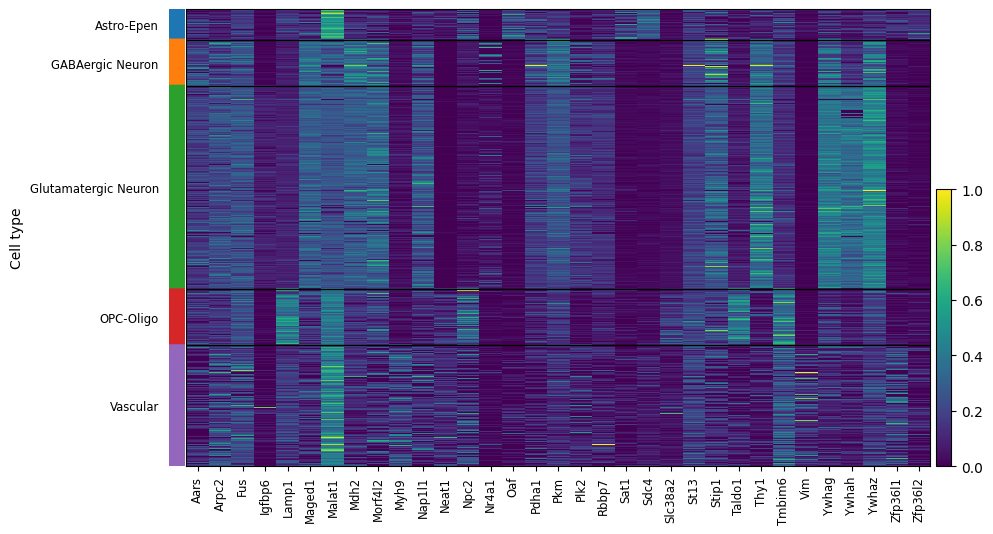

<Figure size 640x480 with 0 Axes>

In [73]:
sc.pl.heatmap(rssf_cell_consensus, groupby='Cell type', var_names = rssf_cell_consensus.uns['gs_sc_pred'], standard_scale="var")
plt.savefig('consensus_gxc_mat_celltype.pdf')

plt.savefig('consensus_gxc_mat_celltype.png')
plt.savefig('consensus_gxc_mat_celltype.svg')
